In [2]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging
import seaborn as sns


working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/for_submission/"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)



# dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42 

Running Scanpy 1.11.5, on 2026-04-20 10:23.


In [7]:
FB_adata = sc.read ('/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_Fibroblasts_PIG_RAW.h5ad')

In [3]:
dea_fb_annotated = sc.read ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/For_Manuscript/files/DEA_FB_annotated_adata.h5ad")

In [49]:
dea_fb_annotated

AnnData object with n_obs × n_vars = 16322 × 3571
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states', 'leiden_07'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Endpoint_status_colors', 'Sample_ID_colors', 'cell_states_colors', 'dendrogram_cell_states', 'hvg', 'leiden', 'leiden_07_colors', 'leiden_08_colors', 'log1p', 'neighbors', 'pca', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap'
    var

In [172]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

# Make sure the DE key exists
assert "wilcoxon" in FB_adata.uns, "Run sc.tl.rank_genes_groups(..., key_added='wilcoxon') first."

save_dir_results = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/For_Manuscript/Results/"
os.makedirs(save_dir_results, exist_ok=True)

mp = sc.pl.rank_genes_groups_matrixplot(
    FB_adata,
    key="wilcoxon",
    n_genes=3,
        figsize=(9, 2),
    standard_scale="var",
    show=False,        # do not display
    return_fig=True    # return a Figure-like object
)

mp.savefig(os.path.join(save_dir_results, "DEA_FB_Matrixplot_3_genes.pdf"),
           dpi=300, bbox_inches="tight", format="pdf")
plt.close("all")


In [8]:
import pandas as pd

# Your mapping table (you can also load it from CSV if you saved it separately)
mapping_df = pd.DataFrame({
    "Sample_ID": [
        "PAV66","PAV82","PAV75","PAV78","PAV72","PAV85","PAV65","PAV76","PAV71","PAV86",
        "PAV68","PAV84","PAV73","PAV79","PAV74","PAV83","PAV67","PAV69","PAV80",
        "B","E","F","G"
    ],
    "Condition_subsets": [
        "3month protocol","3month protocol","3month protocol","Rejection","6month protocol",
        "6month protocol","3month protocol","Rejection","6month protocol","Rejection",
        "PCMV/PRV","Prematurely terminated","PCMV/PRV","Rejection","PCMV/PRV","Prematurely terminated",
        "3month protocol","3month protocol","3month protocol",
        "Control","Control","Control","Control"
    ]
})

# Merge into obs using Sample_ID
FB_adata.obs = FB_adata.obs.merge(
    mapping_df,
    on="Sample_ID",
    how="left"
)

# Quick check
print(FB_adata.obs[['Sample_ID','Condition_subsets']].head())


  Sample_ID Condition_subsets
0     PAV66   3month protocol
1     PAV66   3month protocol
2     PAV66   3month protocol
3     PAV66   3month protocol
4     PAV66   3month protocol


In [9]:
import pandas as pd

# Your mapping table (you can also load it from CSV if you saved it separately)
mapping_df = pd.DataFrame({
    "Sample_ID": [
        "PAV66","PAV82","PAV75","PAV78","PAV72","PAV85","PAV65","PAV76","PAV71","PAV86",
        "PAV68","PAV84","PAV73","PAV79","PAV74","PAV83","PAV67","PAV69","PAV80",
        "B","E","F","G"
    ],
    "Condition_subsets": [
        "3month protocol","3month protocol","3month protocol","Rejection","6month protocol",
        "6month protocol","3month protocol","Rejection","6month protocol","Rejection",
        "PCMV/PRV","Prematurely terminated","PCMV/PRV","Rejection","PCMV/PRV","Prematurely terminated",
        "3month protocol","3month protocol","3month protocol",
        "Control","Control","Control","Control"
    ]
})

# Merge into obs using Sample_ID
dea_fb_annotated.obs = dea_fb_annotated.obs.merge(
    mapping_df,
    on="Sample_ID",
    how="left"
)

# Quick check
print(dea_fb_annotated.obs[['Sample_ID','Condition_subsets']].head())


  Sample_ID Condition_subsets
0     PAV66   3month protocol
1     PAV66   3month protocol
2     PAV66   3month protocol
3     PAV66   3month protocol
4     PAV66   3month protocol


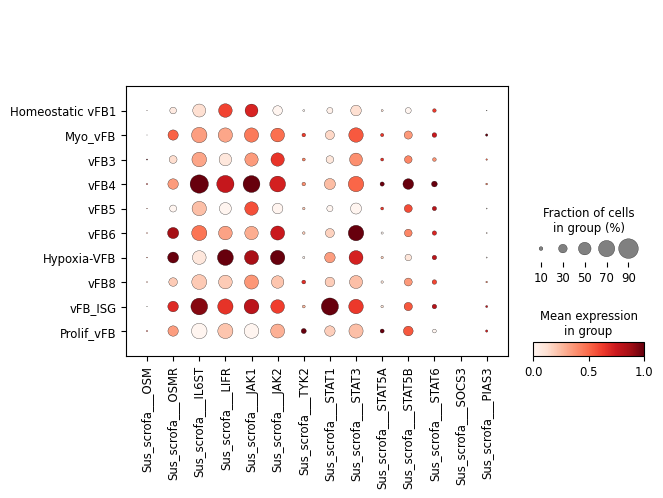

In [10]:
osm_core = [
    'Sus_scrofa___OSM', 'Sus_scrofa___OSMR', 'Sus_scrofa___IL6ST', 'Sus_scrofa___LIFR',
    'Sus_scrofa___JAK1', 'Sus_scrofa___JAK2', 'Sus_scrofa___TYK2',
    'Sus_scrofa___STAT1', 'Sus_scrofa___STAT3', 'Sus_scrofa___STAT5A',
    'Sus_scrofa___STAT5B', 'Sus_scrofa___STAT6',
    'Sus_scrofa___SOCS3', 'Sus_scrofa___PIAS3'
]

sc.pl.dotplot(
    dea_fb_annotated, 
    var_names=osm_core, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

In [11]:
sc.tl.score_genes(dea_fb_annotated, gene_list=osm_core, score_name='osm_core')

scores_df = dea_fb_annotated.obs[['osm_core', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['osm_core'].median().reset_index()


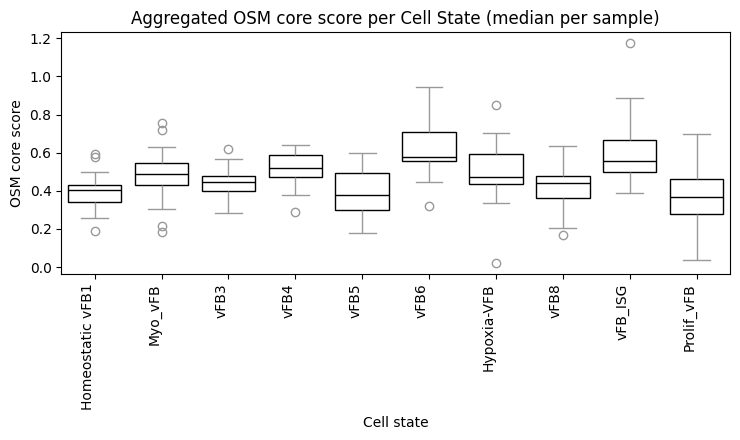

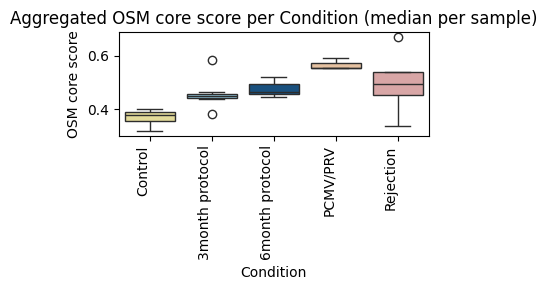

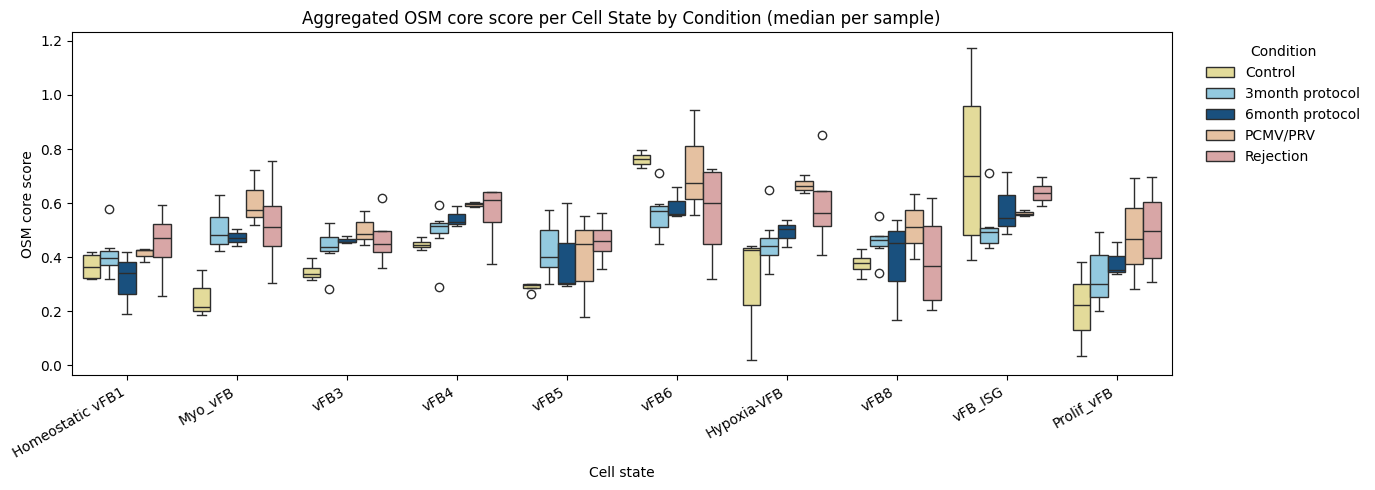

In [12]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Inputs ----------
# Assumes dea_fb_annotated already has:
# - obs columns: 'Sample_ID', 'cell_states', 'Condition_subsets'
# - osm_core score computed in obs['osm_core']

# Custom palette and order you provided
custom_palette = {
    'Control': '#EFE48E',
    '3month protocol': 'skyblue',
    '6month protocol': '#08528f',
    # 'Prematurely terminated': '#C9B8D9',
    'PCMV/PRV': '#F0C096',
    'Rejection': '#E09E9E'
}
hue_order = [
    'Control',
    '3month protocol',
    '6month protocol',
    # 'Prematurely terminated',
    'PCMV/PRV',
    'Rejection'
]

# Ensure Condition_subsets is categorical with the desired order
if 'Condition_subsets' in dea_fb_annotated.obs.columns:
    dea_fb_annotated.obs['Condition_subsets'] = (
        dea_fb_annotated.obs['Condition_subsets']
        .astype('category')
        .cat.set_categories(hue_order, ordered=True)
    )

# ---------- Aggregate per Sample_ID, cell_state, and condition (median) ----------
scores_df = dea_fb_annotated.obs[['osm_core', 'Sample_ID', 'cell_states', 'Condition_subsets']].copy()

agg_scores = (
    scores_df
    .groupby(['Sample_ID', 'cell_states', 'Condition_subsets'], observed=True)['osm_core']
    .median()
    .reset_index()
)

# ---------- Plot 1: Boxplot per Cell State (aggregated per sample) ----------
plt.figure(figsize=(7.5, 4.5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='osm_core',
    color='white',  # neutral fill to focus on states only
    boxprops=dict(edgecolor='black'),
    medianprops=dict(color='black')
)
plt.title('Aggregated OSM core score per Cell State (median per sample)')
plt.xlabel('Cell state')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# ---------- Plot 2: Boxplot per Condition (aggregated per sample across states) ----------
agg_condition = (
    agg_scores
    .groupby(['Sample_ID', 'Condition_subsets'], observed=True)['osm_core']
    .median()
    .reset_index()
)

plt.figure(figsize=(4, 3))
sns.boxplot(
    data=agg_condition,
    x='Condition_subsets',
    y='osm_core',
    order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Condition (median per sample)')
plt.xlabel('Condition')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# ---------- Plot 3: Boxplot per Cell State × Condition ----------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='osm_core',
    hue='Condition_subsets',
    hue_order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Cell State by Condition (median per sample)')
plt.xlabel('Cell state')
plt.ylabel('OSM core score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()


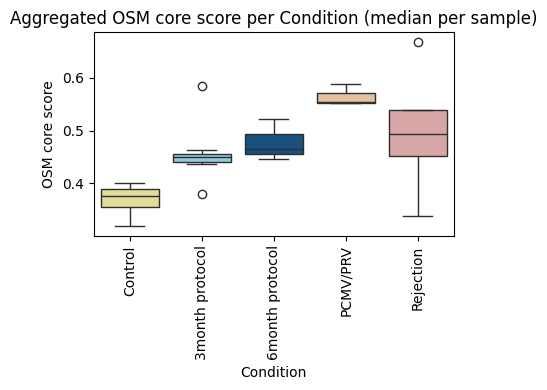

<Figure size 640x480 with 0 Axes>

In [14]:
agg_condition = (
    agg_scores
    .groupby(['Sample_ID', 'Condition_subsets'], observed=True)['osm_core']
    .median()
    .reset_index()
)

plt.figure(figsize=(4.5, 4))
sns.boxplot(
    data=agg_condition,
    x='Condition_subsets',
    y='osm_core',
    order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Condition (median per sample)')
plt.xlabel('Condition')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()
# Save the figure as a PDF with 300 DPI
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/For_Manuscript/Results/your_figure_name.pdf', dpi=300)


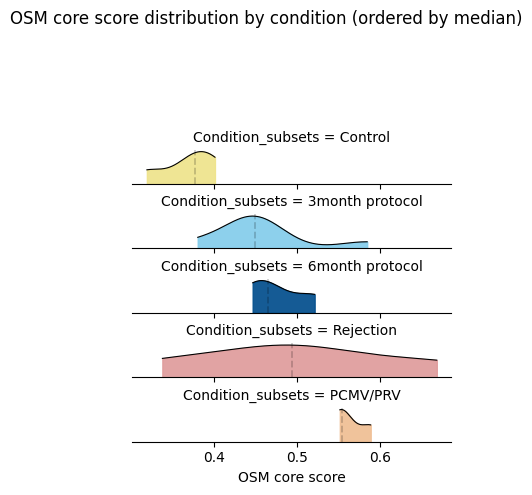

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# sort conditions by their median osm_core (low → high)
order_by_median = (agg_condition.groupby('Condition_subsets')['osm_core']
                   .median().sort_values().index.tolist())

g = sns.FacetGrid(
    agg_condition.assign(Condition_subsets=pd.Categorical(
        agg_condition['Condition_subsets'], categories=order_by_median, ordered=True)),
    row='Condition_subsets', hue='Condition_subsets',
    aspect=4, height=1.0, sharex=True, sharey=False,
    palette=custom_palette
)

g.map(sns.kdeplot, 'osm_core', fill=True, alpha=0.95, bw_adjust=0.8, cut=0)
g.map(sns.kdeplot, 'osm_core', color='black', lw=0.8, bw_adjust=0.8, cut=0)  # outline

# add median line per row
for ax, cond in zip(g.axes.flat, order_by_median):
    m = agg_condition.loc[agg_condition['Condition_subsets']==cond, 'osm_core'].median()
    ax.axvline(m, ls='--', lw=1.3, color='black', alpha=0.2)
    ax.set_ylabel(''); ax.set_yticks([])

g.set_xlabels('OSM core score')
g.fig.subplots_adjust(top=0.7)
g.fig.suptitle('OSM core score distribution by condition (ordered by median)', fontsize=12)
sns.despine(left=True, bottom=False)
plt.show()


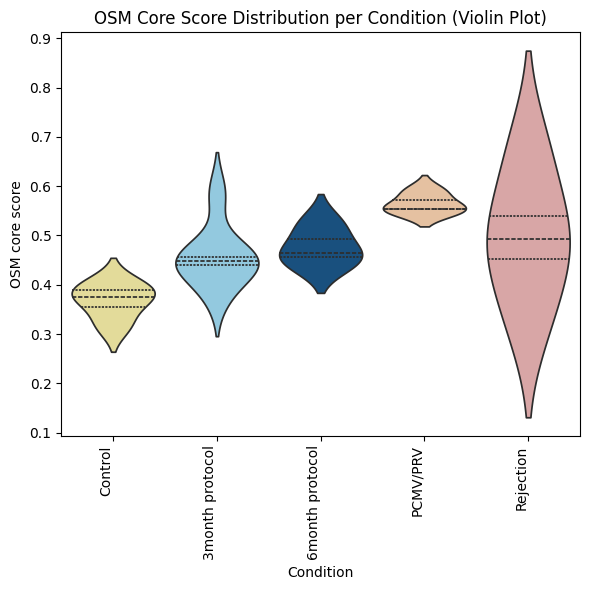

In [16]:
plt.figure(figsize=(6, 6))
sns.violinplot(
    data=agg_condition,
    x='Condition_subsets',
    y='osm_core',
    order=hue_order,
    palette=custom_palette,
    inner='quartile' # Shows the quartiles inside the violin
)
plt.title('OSM Core Score Distribution per Condition (Violin Plot)')
plt.xlabel('Condition')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

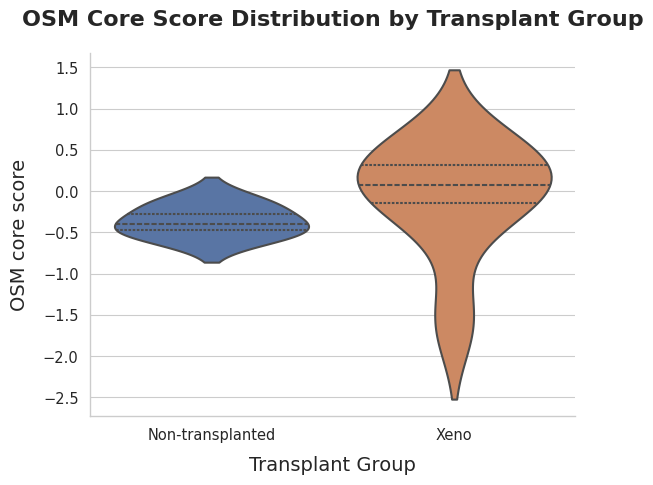

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Creating a Sample DataFrame to simulate your data ---
# Replace this section with your actual data loading/DataFrame
# (e.g., dea_fb_annotated.obs)
data = {
    'Condition_subsets': ['Control', '3month protocol', '6month protocol', 'Control', 'Rejection', 'PCMV/PRV', 'Control', '3month protocol', 'PCMV/PRV', 'Rejection'],
    'osm_core': np.random.randn(10) * 0.5 + 0.1, # Sample data for osm_core
}
obs_data = pd.DataFrame(data)

# --- Start of the plotting logic ---
# Create the new grouping column
obs_data['transplant_group'] = obs_data['Condition_subsets'].apply(
    lambda x: 'Non-transplanted' if x == 'Control' else 'Xeno'
)

# Ensure the new grouping is a categorical variable with a defined order
obs_data['transplant_group'] = pd.Categorical(
    obs_data['transplant_group'],
    categories=['Non-transplanted', 'Xeno'],
    ordered=True
)

# Set up the plotting style for a clean, manuscript-ready figure
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Create a custom palette for the new groups
group_palette = {
    'Non-transplanted': '#4c72b0', # A muted blue
    'Xeno': '#dd8452' # A muted orange
}

# Create the violin plot
plt.figure(figsize=(6, 5))
sns.violinplot(
    data=obs_data,
    x='transplant_group',
    y='osm_core',
    palette=group_palette,
    inner='quartile', # Shows quartiles inside the violin
    linewidth=1.5
)

# Add titles and labels with improved formatting
plt.title(
    'OSM Core Score Distribution by Transplant Group',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel('Transplant Group', fontsize=14, labelpad=10)
plt.ylabel('OSM core score', fontsize=14, labelpad=10)

# Use tight_layout for a clean fit and display the plot
plt.tight_layout()
plt.show()